<a href="https://colab.research.google.com/github/nnm23is101-afk/Deep-learning-Course--Nitte/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1, Loss: 0.2098, Acc: 0.9337
Epoch 2, Loss: 0.1372, Acc: 0.9503
Epoch 3, Loss: 0.0994, Acc: 0.9597
Epoch 4, Loss: 0.0755, Acc: 0.9600
Epoch 5, Loss: 0.0558, Acc: 0.9637
Epoch 6, Loss: 0.0458, Acc: 0.9633
Epoch 7, Loss: 0.0338, Acc: 0.9635
Epoch 8, Loss: 0.0228, Acc: 0.9665
Epoch 9, Loss: 0.0164, Acc: 0.9675
Epoch 10, Loss: 0.0120, Acc: 0.9677


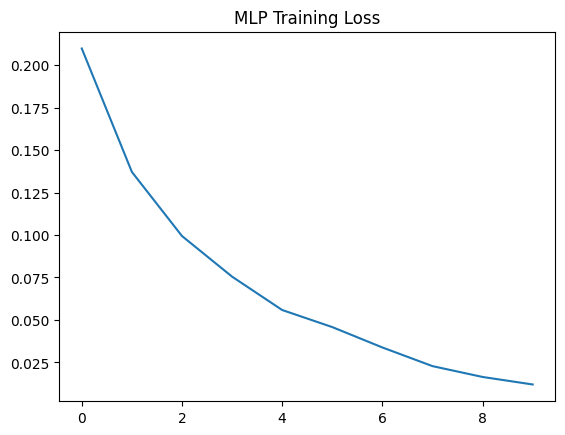

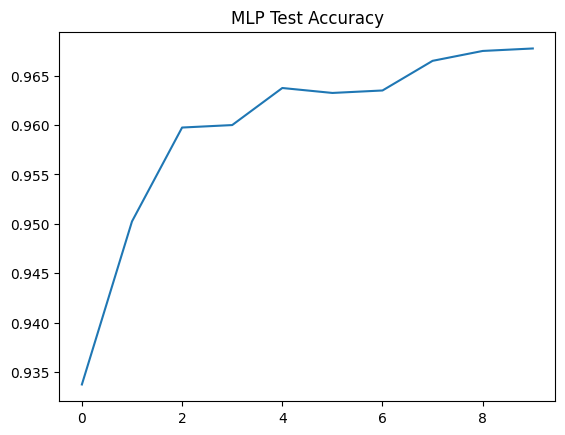

AE Epoch: 1 Loss: 0.09359406361484264
AE Epoch: 2 Loss: 0.08705920848073032
AE Epoch: 3 Loss: 0.08047395160171239
AE Epoch: 4 Loss: 0.0953492062646693
AE Epoch: 5 Loss: 0.059462254340669624
AE Epoch: 6 Loss: 0.04963078295150409
AE Epoch: 7 Loss: 0.045435937059390294
AE Epoch: 8 Loss: 0.043539384780176424
AE Epoch: 9 Loss: 0.03895506424542117
AE Epoch: 10 Loss: 0.035478745913076336


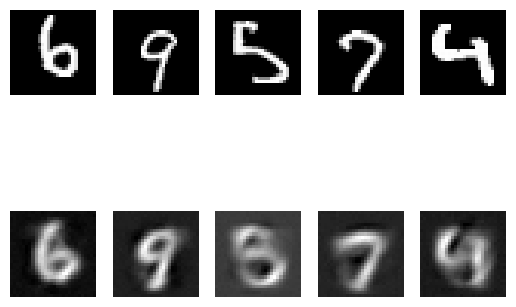

RBM Epoch: 1
RBM Epoch: 2
RBM Epoch: 3
RBM Epoch: 4
RBM Epoch: 5


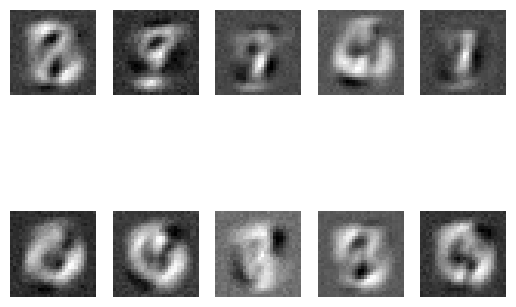

Outlier Threshold: 0.07358425467381119


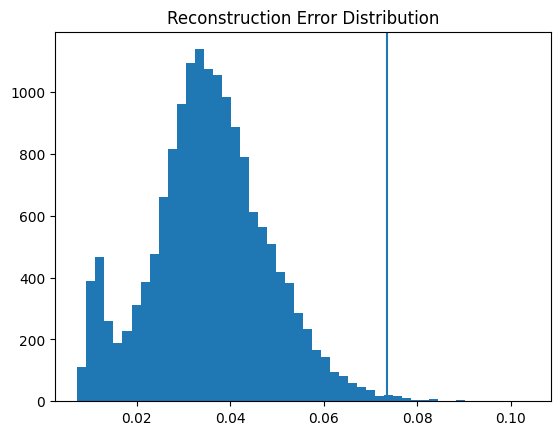

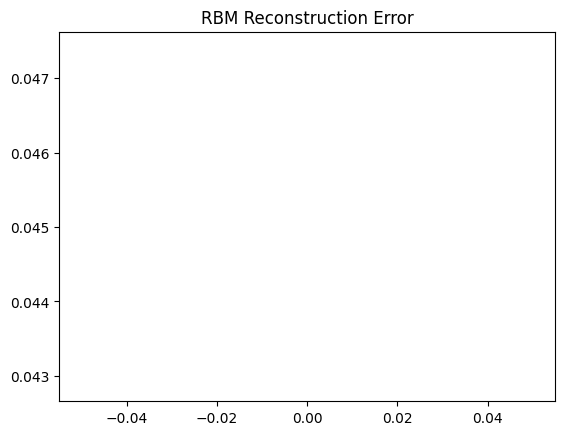

Final MLP Accuracy: 0.96775
Final MLP Loss: 0.011988025249783913
Final AE Loss: 0.035478745913076336


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0
y = mnist.target.astype(int)

X = X.values
y = y.values

# Train-test split (use smaller subset for speed)
X_train, X_test, y_train, y_test = train_test_split(
    X[:20000], y[:20000], test_size=0.2, random_state=42)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1,1))
y_test_oh = encoder.transform(y_test.reshape(-1,1))

input_size = 784
hidden_size = 128
output_size = 10
lr = 0.01
epochs = 10
batch_size = 64

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return x > 0

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

train_losses = []
test_accs = []

for epoch in range(epochs):

    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_oh[i:i+batch_size]

        # Forward
        z1 = X_batch @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        y_pred = softmax(z2)

        # Backprop
        dz2 = y_pred - y_batch
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * relu_deriv(z1)
        dW1 = X_batch.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # Track loss
    z1 = X_train @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_pred = softmax(z2)
    loss = cross_entropy(y_train_oh, y_pred)
    train_losses.append(loss)

    # Test accuracy
    z1 = X_test @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_pred = softmax(z2)
    preds = np.argmax(y_pred, axis=1)
    acc = np.mean(preds == y_test)
    test_accs.append(acc)

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Acc: {acc:.4f}")

plt.plot(train_losses)
plt.title("MLP Training Loss")
plt.show()

plt.plot(test_accs)
plt.title("MLP Test Accuracy")
plt.show()

latent_size = 32

W1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros((1,128))
W2 = np.random.randn(128, latent_size) * 0.01
b2 = np.zeros((1,latent_size))

W3 = np.random.randn(latent_size,128) * 0.01
b3 = np.zeros((1,128))
W4 = np.random.randn(128,784) * 0.01
b4 = np.zeros((1,784))

lr = 0.01
epochs = 10

ae_losses = []

for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]

        # Forward
        h1 = relu(X_batch @ W1 + b1)
        z = relu(h1 @ W2 + b2)
        h2 = relu(z @ W3 + b3)
        X_hat = h2 @ W4 + b4

        loss = np.mean((X_batch - X_hat)**2)

        # Backprop
        dX_hat = 2*(X_hat - X_batch)/batch_size
        dW4 = h2.T @ dX_hat
        db4 = np.sum(dX_hat, axis=0, keepdims=True)

        dh2 = dX_hat @ W4.T
        dh2 *= relu_deriv(h2)
        dW3 = z.T @ dh2
        db3 = np.sum(dh2, axis=0)

        dz = dh2 @ W3.T
        dz *= relu_deriv(z)
        dW2 = h1.T @ dz
        db2 = np.sum(dz, axis=0)

        dh1 = dz @ W2.T
        dh1 *= relu_deriv(h1)
        dW1 = X_batch.T @ dh1
        db1 = np.sum(dh1, axis=0)

        # Update
        W1 -= lr*dW1
        W2 -= lr*dW2
        W3 -= lr*dW3
        W4 -= lr*dW4

    ae_losses.append(loss)
    print("AE Epoch:", epoch+1, "Loss:", loss)

sample = X_test[:5]
h1 = relu(sample @ W1 + b1)
z = relu(h1 @ W2 + b2)
h2 = relu(z @ W3 + b3)
recon = h2 @ W4 + b4

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(sample[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.subplot(2,5,i+6)
    plt.imshow(recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

hidden = 128
W = np.random.randn(784, hidden) * 0.01
hb = np.zeros((1,hidden))
vb = np.zeros((1,784))
lr = 0.01
epochs = 5

def sigmoid(x):
    return 1/(1+np.exp(-x))

for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        v0 = X_train[i:i+batch_size]

        h_prob = sigmoid(v0 @ W + hb)
        h_state = h_prob > np.random.rand(*h_prob.shape)

        v_prob = sigmoid(h_state @ W.T + vb)
        h_prob2 = sigmoid(v_prob @ W + hb)

        W += lr * (v0.T @ h_prob - v_prob.T @ h_prob2)/batch_size

    print("RBM Epoch:", epoch+1)

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(W[:,i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

hidden_size = 64

hidden_size = 256

loss = np.mean((X_batch - X_hat)**2)

l1_lambda = 0.0001
loss = np.mean((X_batch - X_hat)**2) + l1_lambda * np.mean(np.abs(z))

recon_errors = []

for i in range(X_train.shape[0]):
    x = X_train[i:i+1]
    h1 = relu(x @ W1 + b1)
    z = relu(h1 @ W2 + b2)
    h2 = relu(z @ W3 + b3)
    x_hat = h2 @ W4 + b4
    error = np.mean((x - x_hat)**2)
    recon_errors.append(error)

recon_errors = np.array(recon_errors)

threshold = np.mean(recon_errors) + 3*np.std(recon_errors)

print("Outlier Threshold:", threshold)

plt.hist(recon_errors, bins=50)
plt.axvline(threshold)
plt.title("Reconstruction Error Distribution")
plt.show()

rbm_errors = []

error = np.mean((v0 - v_prob)**2)
rbm_errors.append(error)

plt.plot(rbm_errors)
plt.title("RBM Reconstruction Error")
plt.show()

print("Final MLP Accuracy:", test_accs[-1])
print("Final MLP Loss:", train_losses[-1])
print("Final AE Loss:", ae_losses[-1])